## Preparation

In [26]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from data_generation.models.tech_substitution import TechnologySubstitution
from data_generation.models.tech_substitution import TechSubNumericalSolver
from data_generation.models.general_ode_solver import FitzHughNagumoModel
from data_generation.models.simple_test_models import SteadyHorizontalFlow
from data_generation.models.general_ode_solver import GeneralODENumericalSolver
from data_generation.simulations.grid import Grid, fractional_transformation, logistic_transformation
from data_generation.simulations.simulator import run_and_store_simulations, Simulator
from clustering.patchwork_visualization import plot_entropy_overlay
from data_generation.visualization.create_plots import plot_2D_vector_field_over_grid
from datasets.data_reconstruction import get_and_reconstruct_data, reconstruct_solver_and_grid
from clustering.patchwork import create_patchwork, Patchwork
from clustering.correctness_test_plots import plot_trajectories_in_transformed_space

In [27]:
results_dir = os.path.join(parent_dir, 'datasets', 'results')
OUTPUT_DIR = Path.cwd().parent/ "datasets" / "results" 
OUTPUT_DIR_SIMPLE = Path.cwd().parent/ "datasets" / "results" / "simple_models"

In [28]:
#Create the simple_models_run_dict #Overwrites EVERYTHING, Take care!
'''
simple_models_run_dict = dict()
simple_models_run_dict['SteadyHorizontalFlow'] = dict()
simple_models_run_dict['SteadyHorizontalFlow'][0] = None

# Save the simple_models_run_dict to a JSON file
with open(OUTPUT_DIR / "simple_models_run_dict.json", "w") as file:
    json.dump(simple_models_run_dict, file, indent=4)
'''


'\nsimple_models_run_dict = dict()\nsimple_models_run_dict[\'SteadyHorizontalFlow\'] = dict()\nsimple_models_run_dict[\'SteadyHorizontalFlow\'][0] = None\n\n# Save the simple_models_run_dict to a JSON file\nwith open(OUTPUT_DIR / "simple_models_run_dict.json", "w") as file:\n    json.dump(simple_models_run_dict, file, indent=4)\n'

In [29]:
# Open the JSON file again and read its content
with open(OUTPUT_DIR_SIMPLE / "simple_models_run_dict.json", "r") as file:
    simple_models_run_dict = json.load(file)

# Open the JSON file again and read its content
with open(OUTPUT_DIR / "run_dict.json", "r") as file:
    run_dict = json.load(file)



In [30]:
def update_run_dict(model_run_dict, num_samples_per_cell, resolution, controls, transformations, trafo_params, delta_t, comment = None):
    next_key = sorted([int(key) for key in model_run_dict.keys()])[-1] +1 
    model_run_dict[next_key] = dict()
    model_run_dict[next_key]['run_ids'] = list()
    model_run_dict[next_key]['resolution'] = resolution
    model_run_dict[next_key]['num_samples_per_cell'] = num_samples_per_cell
    model_run_dict[next_key]['controls'] = [list(control) for control in controls]
    model_run_dict[next_key]['delta_t'] = delta_t
    model_run_dict[next_key]['transformations'] = None if transformations== None else ([tf[0].__name__ for tf in transformations], trafo_params)
    model_run_dict[next_key]['comment'] = comment

    return next_key

In [31]:
def streamline_and_entropy_plot(db_name, table_name, run_ids, res = 21):
    
    df, configs_dict = get_and_reconstruct_data(db_name, table_name, run_ids)
    grid, solver = reconstruct_solver_and_grid(run_ids[0], configs_dict)
    
    if grid.bounds[0][-1] == np.inf:
        patchwork, controls, solver = create_patchwork(db_name, table_name, run_ids)
    else:
        df = df[df['y'].apply(lambda y: max(y) <= grid.bounds[0][-1])] #as we run out of the defined space
        patchwork = Patchwork(grid,df)
        controls = df['c'].unique() #np.array([np.array(control) for control in df['c'].unique()])

    fig, axes = plt.subplots(figsize=(8, 8))
    plot_2D_vector_field_over_grid(patchwork.grid, solver, controls[0], display_vectorfield=False, resolution=res, ax= axes, streamplot_colour='blue', broken_streamlines=False)
    plot_entropy_overlay(axes, patchwork, cmap='viridis', alpha=0.5)
    plt.show()
    return patchwork


## Steady Horizontal Flow

In [12]:
trafo_params = [3,3]# [{'k': 1, 'x_0': 0}, {'k': 1, 'x_0': 0}]
transformations =[fractional_transformation(trafo_params[0]), fractional_transformation(trafo_params[0])] #
#transformations = [logistic_transformation(trafo_params[0]), logistic_transformation(trafo_params[1])] #None #
bounds = [(0, np.inf), (0, np.inf)] #[(-np.inf,np.inf),(-np.inf,np.inf)] #[(0,10),(0,10)]#
model = SteadyHorizontalFlow(control_params=['c'])
solver = GeneralODENumericalSolver(model)
controls = np.array([[5.0]])
resolution = [10,10]
num_samples_per_cell = 200
num_steps = 1
delta_t = 0.5

next_key = update_run_dict(simple_models_run_dict['SteadyHorizontalFlow'],num_samples_per_cell, resolution, controls, transformations, trafo_params, delta_t)


In [13]:
for control in controls:
    simulator = run_and_store_simulations(OUTPUT_DIR_SIMPLE, 
                          bounds, 
                          transformations, 
                          model, 
                          solver, 
                          control, 
                          resolution,
                          num_samples_per_cell,
                          num_steps,
                          delta_t)
    simple_models_run_dict['SteadyHorizontalFlow'][next_key]['run_ids'].append(simulator.configs['run_id'][0])

with open(OUTPUT_DIR / 'simple_models'/ "simple_models_run_dict.json", "w") as file:
    json.dump(simple_models_run_dict, file, indent=4)

Simulation complete:
- 20000 samples × 1 timesteps = 20000 total rows
- State dimensions: 2
- Control dimensions: 1
Saved results and config.
Stored 20000 rows of simulation data in /home/kstiller/masterthesis/Coding/mdp-world-model/datasets/results/simple_models/simulation_results.db

Configs data:
            run_id                                           metadata
0  20250327_175935  {"configurations": {"grid": {"bounds": [[0, In...

Results data:
            run_id trajectory_id   t0   t1        x0        x1   c0        y0  \
0  20250327_175935         0-0_0  0.0  0.5  0.320077  0.234427  5.0  2.820077   
1  20250327_175935         0-0_1  0.0  0.5  0.149905  0.010150  5.0  2.649905   
2  20250327_175935         0-0_2  0.0  0.5  0.108426  0.083312  5.0  2.608426   
3  20250327_175935         0-0_3  0.0  0.5  0.285763  0.031630  5.0  2.785763   
4  20250327_175935         0-0_4  0.0  0.5  0.167532  0.160994  5.0  2.667532   

         y1  
0  2.734427  
1  2.510150  
2  2.583312  
3

## Plotting

All configurations are the same: True


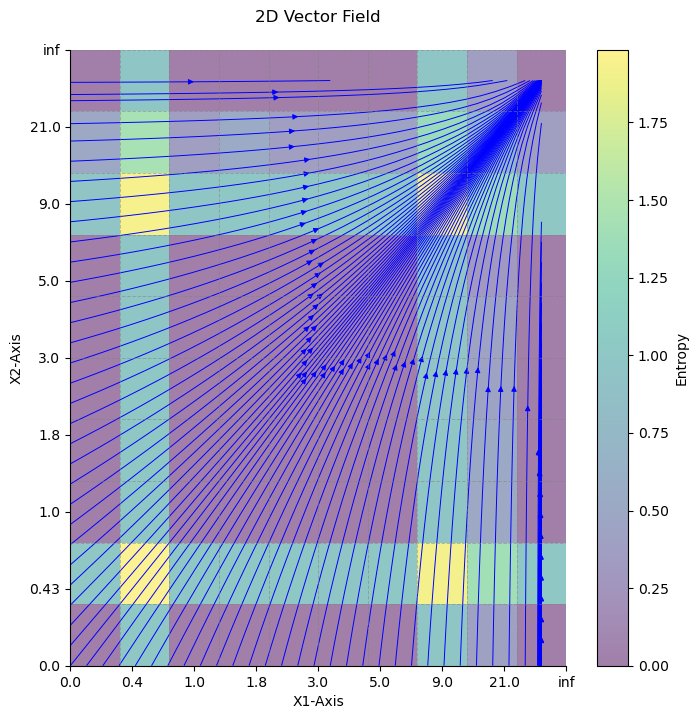

In [7]:
db_name = os.path.join(results_dir, 'simple_models','simulation_results.db')
table_name = 'SteadyHorizontalFlow_c' 
run_ids = simple_models_run_dict['SteadyHorizontalFlow']['26']['run_ids']
patchwork = streamline_and_entropy_plot(db_name, table_name, run_ids)

<Axes: title={'center': 'Trajectories in Transformed Space'}, xlabel='X1-Axis', ylabel='X2-Axis'>

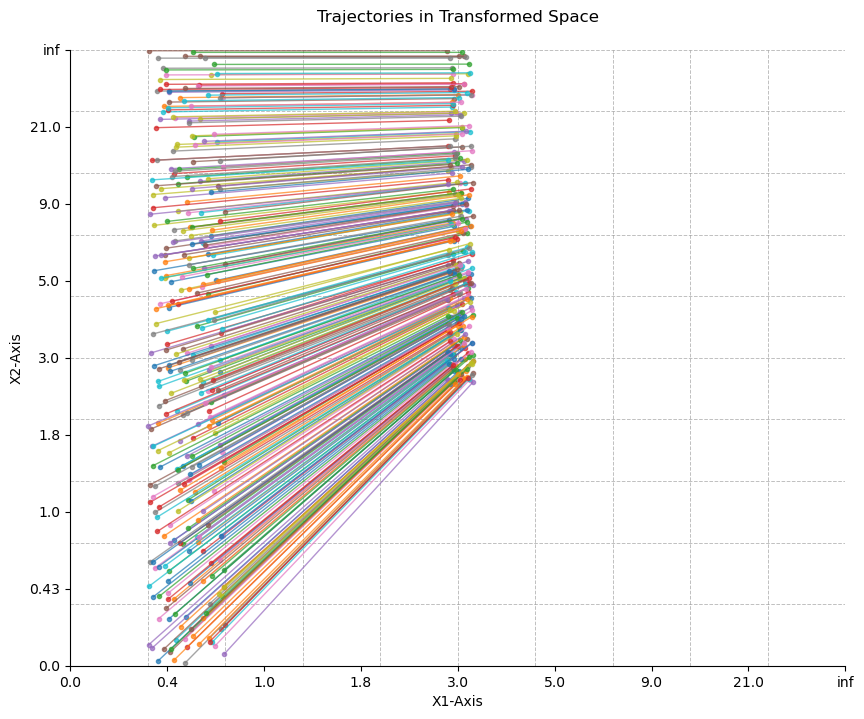

In [11]:
df, configs_dict = get_and_reconstruct_data(db_name, table_name, run_ids)
grid, solver = reconstruct_solver_and_grid(run_ids[0], configs_dict)
controls = np.array([[5.0]])
patch_ids = set(range(10,20))

plot_trajectories_in_transformed_space(patchwork.action_df, patchwork.grid, solver, controls, max_trajectories=300, plot_vector_field=False, patch_ids= patch_ids)

All configurations are the same: True


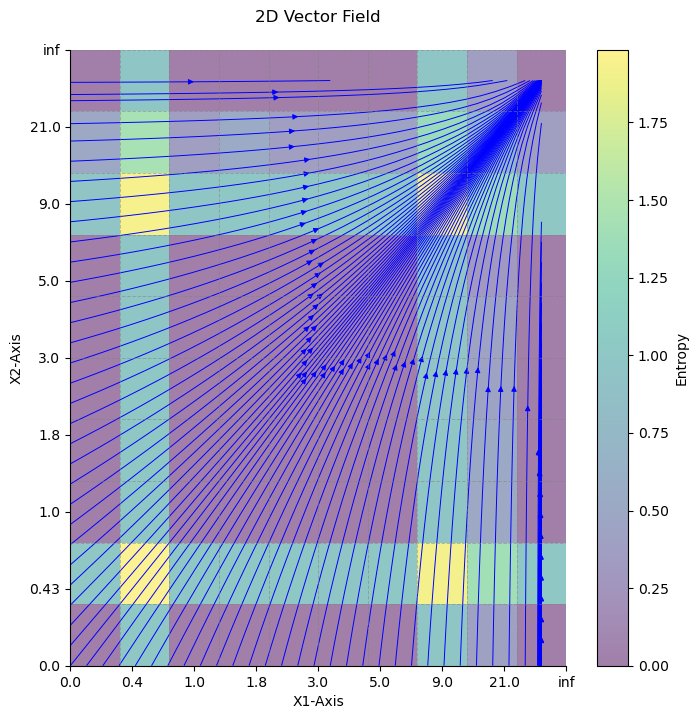

In [13]:
db_name = os.path.join(results_dir, 'simple_models','simulation_results.db')
table_name = 'SteadyHorizontalFlow_c' 
run_ids = simple_models_run_dict['SteadyHorizontalFlow']['26']['run_ids']
patchwork = streamline_and_entropy_plot(db_name, table_name, run_ids)

In [ ]:
patchwork.action_df

,run_id,trajectory_id,t0,t1,x,y,a,x_cell,y_cell,x_patch_id,y_patch_id
0,20250327_173312,0-0_0,0.0,0.5,"[0.015619130393680838, 0.002251727057585204]","[2.515619130393681, 2.502251727057585]",0,"(0, 0)","(13, 13)",0,403
1,20250327_173312,0-0_1,0.0,0.5,"[0.07014834639946146, 0.015960777305539162]","[2.570148346399461, 2.515960777305539]",0,"(0, 0)","(13, 13)",0,403
2,20250327_173312,0-0_2,0.0,0.5,"[0.07806328952585846, 0.02232894366049162]","[2.578063289525858, 2.5223289436604914]",0,"(0, 0)","(13, 13)",0,403
3,20250327_173312,0-0_3,0.0,0.5,"[0.051907035164607915, 0.029074084774461502]","[2.5519070351646076, 2.5290740847744613]",0,"(0, 0)","(13, 13)",0,403
4,20250327_173312,0-0_4,0.0,0.5,"[0.002787015870521216, 0.04094706932034473]","[2.502787015870521, 2.5409470693203446]",0,"(0, 0)","(13, 13)",0,403
...,...,...,...,...,...,...,...,...,...,...,...
179995,20250327_173312,29-29_195,0.0,0.5,"[89.81694452083244, 90.081018413645]","[92.31694452083244, 92.581018413645]",0,"(29, 29)","(29, 29)",899,899
179996,20250327_173312,29-29_196,0.0,0.5,"[187.67285630410285, 2360.13300346119]","[190.17285630410282, 2362.6330034611906]",0,"(29, 29)","(29, 29)",899,899
179997,20250327_173312,29-29_197,0.0,0.5,"[90.26452453243816, 130.97580575463988]","[92.76452453243816, 133.47580575463985]",0,"(29, 29)","(29, 29)",899,899
179998,20250327_173312,29-29_198,0.0,0.5,"[151.03590908048193, 108.66808941742674]","[153.5359090804819, 111.16808941742674]",0,"(29, 29)","(29, 29)",899,899


All configurations are the same: True


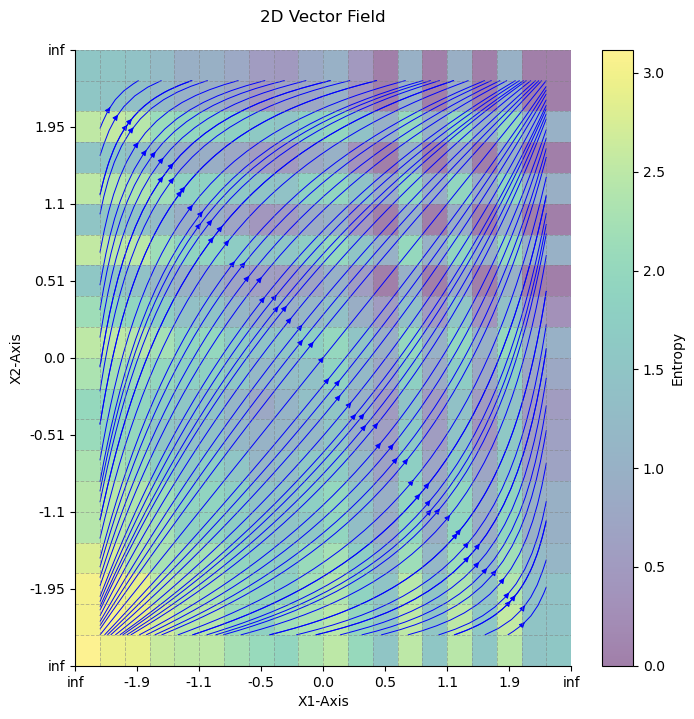

In [9]:
db_name = os.path.join(results_dir, 'simple_models','simulation_results.db')
table_name = 'SteadyHorizontalFlow_c' 
run_ids = simple_models_run_dict['SteadyHorizontalFlow']['11']['run_ids']
patchwork = streamline_and_entropy_plot(db_name, table_name, run_ids)

In [31]:
patchwork.trans_probs

{0: {0: {44: 1.0}},
 1: {0: {44: 0.455, 45: 0.545}},
 2: {0: {45: 1.0}},
 3: {0: {45: 1.0}},
 4: {0: {46: 1.0}},
 5: {0: {46: 1.0}},
 6: {0: {47: 1.0}},
 7: {0: {47: 0.64, 48: 0.36}},
 8: {0: {48: 0.89, 49: 0.11}},
 9: {0: {49: 1.0}},
 10: {0: {44: 0.435, 54: 0.565}},
 11: {0: {44: 0.235, 45: 0.225, 54: 0.225, 55: 0.315}},
 12: {0: {45: 0.435, 55: 0.565}},
 13: {0: {45: 0.515, 55: 0.485}},
 14: {0: {46: 0.515, 56: 0.485}},
 15: {0: {46: 0.41, 56: 0.59}},
 16: {0: {47: 0.41, 57: 0.59}},
 17: {0: {47: 0.225, 48: 0.15, 57: 0.365, 58: 0.26}},
 18: {0: {48: 0.36, 49: 0.03, 58: 0.535, 59: 0.075}},
 19: {0: {49: 0.415, 59: 0.585}},
 20: {0: {54: 1.0}},
 21: {0: {54: 0.45, 55: 0.55}},
 22: {0: {55: 1.0}},
 23: {0: {55: 1.0}},
 24: {0: {56: 1.0}},
 25: {0: {56: 1.0}},
 26: {0: {57: 1.0}},
 27: {0: {57: 0.615, 58: 0.385}},
 28: {0: {58: 0.93, 59: 0.07}},
 29: {0: {59: 1.0}},
 30: {0: {54: 1.0}},
 31: {0: {54: 0.445, 55: 0.555}},
 32: {0: {55: 1.0}},
 33: {0: {55: 1.0}},
 34: {0: {56: 1.0}},
 35:

All configurations are the same: True


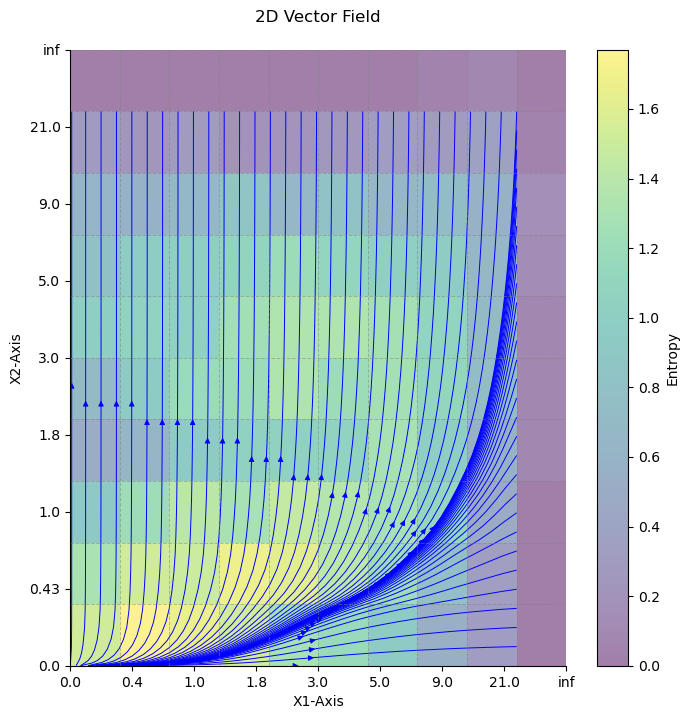

In [11]:
db_name = os.path.join(results_dir, 'simulation_results.db')
table_name = 'TechnologySubstitution_gamma2' 
run_ids = run_dict['TechSub']['2']['run_ids']
streamline_and_entropy_plot(db_name, table_name, run_ids, res = 11)

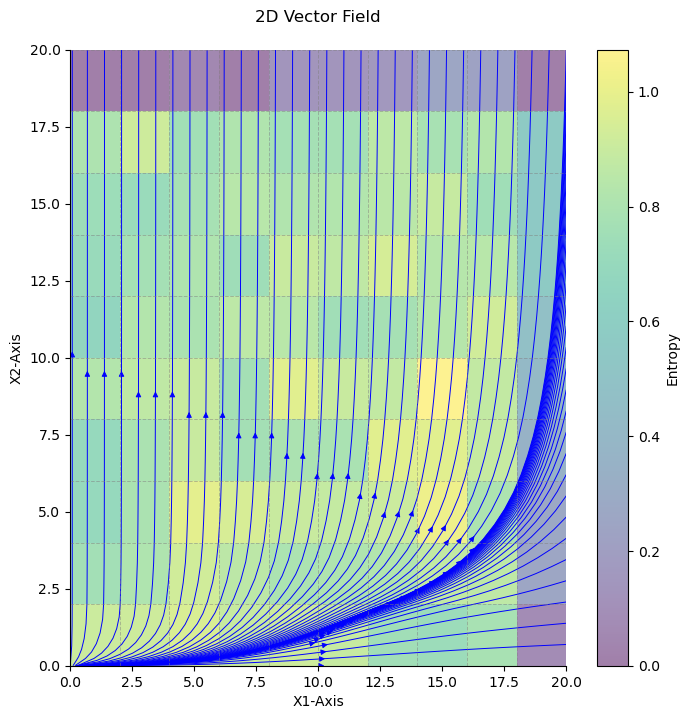

In [12]:
db_name = os.path.join(results_dir, 'simulation_results.db')
table_name = 'TechnologySubstitution_gamma2' 
run_ids = run_dict['TechSub']['4']['run_ids']
streamline_and_entropy_plot(db_name, table_name, run_ids, res = 11)

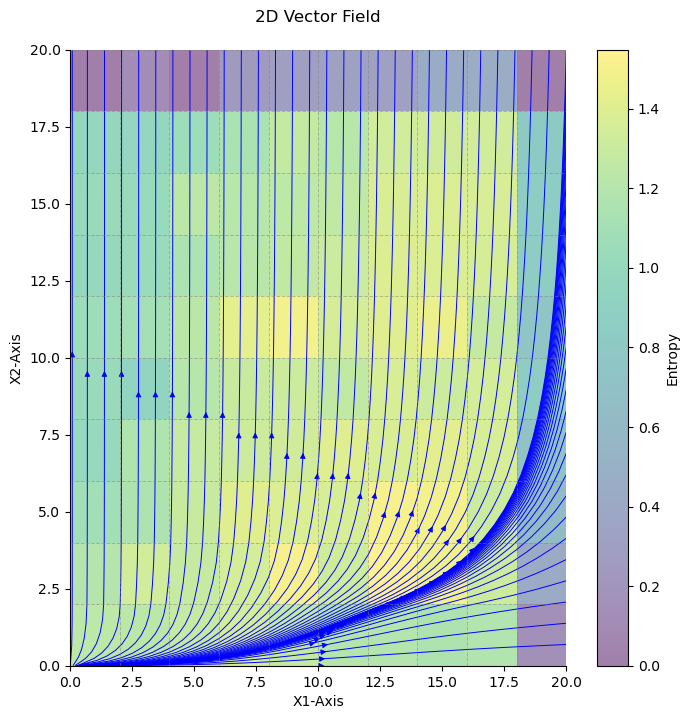

In [13]:
db_name = os.path.join(results_dir, 'simulation_results.db')
table_name = 'TechnologySubstitution_gamma2' 
run_ids = run_dict['TechSub']['3']['run_ids']
df = streamline_and_entropy_plot(db_name, table_name, run_ids, res = 11)

All configurations are the same: True


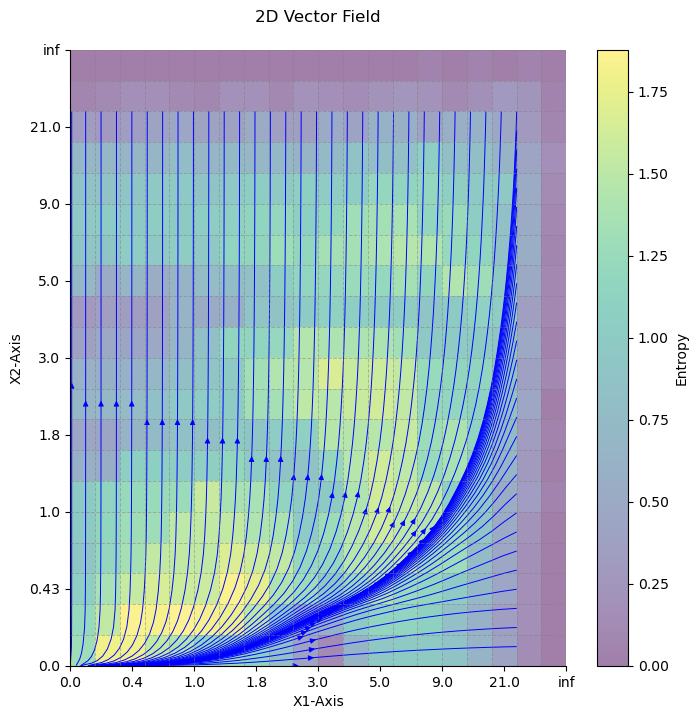

In [32]:
db_name = os.path.join(results_dir, 'simulation_results.db')
table_name = 'TechnologySubstitution_gamma2' 
run_ids = ['20250325_082156', '20250325_083742'] #for 20 by 20 TechSub (with 100 samples per cell)
patchwork = streamline_and_entropy_plot(db_name, table_name, run_ids, res = 11)


<Axes: title={'center': 'Trajectories in Transformed Space'}, xlabel='X1-Axis', ylabel='X2-Axis'>

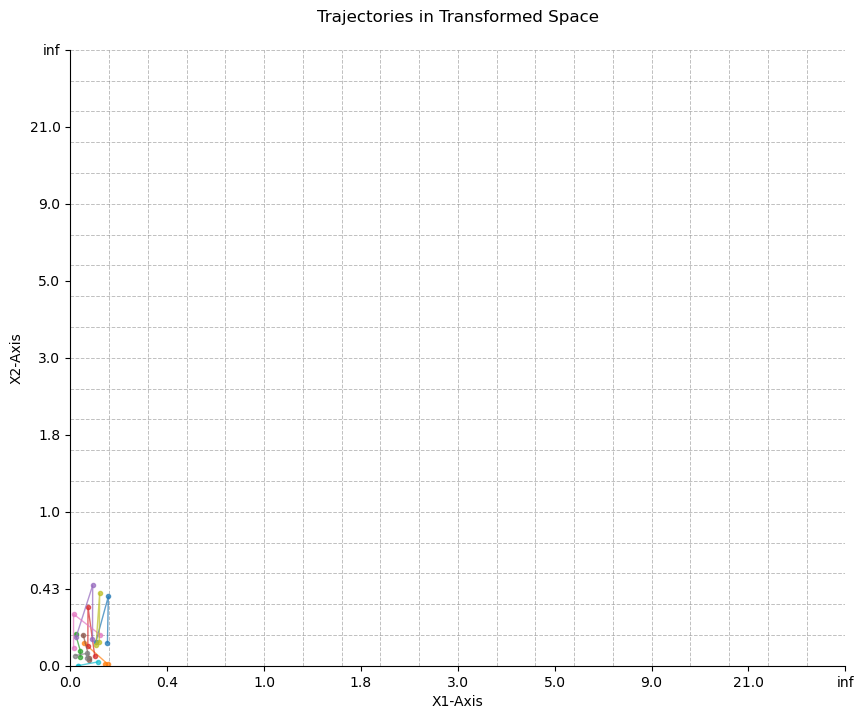

In [ ]:
df, configs_dict = get_and_reconstruct_data(db_name, table_name, run_ids)
grid, solver = reconstruct_solver_and_grid(run_ids[0], configs_dict)
controls = df['c'].unique() 
patch_ids = {0}

plot_trajectories_in_transformed_space(patchwork.action_df, patchwork.grid, solver, controls[0], max_trajectories=10, plot_vector_field=False, patch_ids= patch_ids)

#Problem: it's only grouped by traj_ids, not actions!!!

In [25]:
patchwork.action_df.groupby('trajectory_id').head()

,run_id,trajectory_id,t0,t1,x,y,a,x_cell,y_cell,x_patch_id,y_patch_id
0,20250325_082156,0-0_0,0.0,1.3,"[0.06740429130185022, 0.1383613635745223]","[0.0678075473934157, 0.46632953565424673]",0,"(0, 0)","(0, 2)",0,2
1,20250325_082156,0-0_1,0.0,1.3,"[0.05853356997009103, 0.01422451009192415]","[0.05962713287631771, 0.015316069837957583]",0,"(0, 0)","(0, 0)",0,0
2,20250325_082156,0-0_2,0.0,1.3,"[0.14065092766022305, 0.0901673435575586]","[0.14547751304816944, 0.2735946545645446]",0,"(0, 0)","(0, 1)",0,1
3,20250325_082156,0-0_3,0.0,1.3,"[0.04242861065250907, 0.05491503539429008]","[0.04282188337675907, 0.11007639752508394]",0,"(0, 0)","(0, 0)",0,0
4,20250325_082156,0-0_4,0.0,1.3,"[0.03924268483733344, 0.04443300057125209]","[0.03960162220697819, 0.07277983001738614]",0,"(0, 0)","(0, 0)",0,0
...,...,...,...,...,...,...,...,...,...,...,...
79995,20250325_083742,19-19_95,0.0,1.3,"[94.67006797506794, 194.6601333208183]","[94.84088717768063, 195.70032035926175]",1,"(19, 19)","(19, 19)",399,399
79996,20250325_083742,19-19_96,0.0,1.3,"[61.47369346364198, 68.39495399139136]","[61.97763485681161, 69.05411411686204]",1,"(19, 19)","(19, 19)",399,399
79997,20250325_083742,19-19_97,0.0,1.3,"[77.41581886195158, 181.93377098643035]","[77.54273821363302, 183.01411164761245]",1,"(19, 19)","(19, 19)",399,399
79998,20250325_083742,19-19_98,0.0,1.3,"[165.95095028928338, 165.16091818048307]","[166.5612434559493, 165.76395401749758]",1,"(19, 19)","(19, 19)",399,399


(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Cell Importance Measure'}, xlabel='x1', ylabel='x2'>)

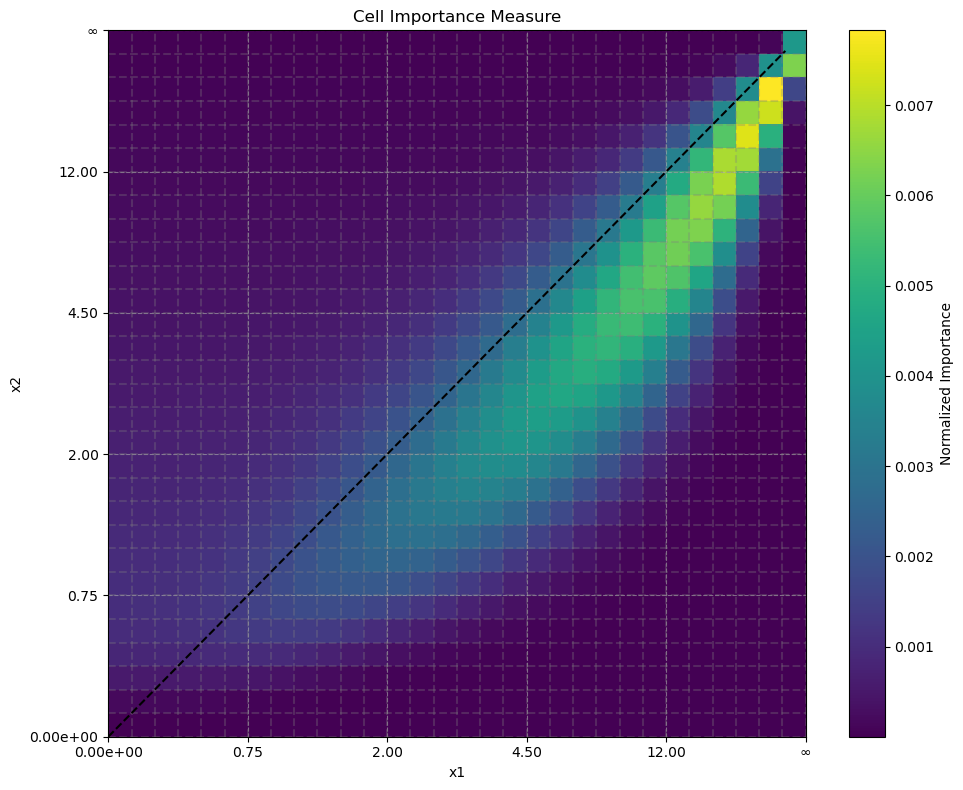

In [18]:
bounds =[(0, np.inf), (0, np.inf)] #
trafo_params =  [3,3]
transformations = [fractional_transformation(trafo_params[0]), fractional_transformation(trafo_params[0])] #

model = TechnologySubstitution()
solver = TechSubNumericalSolver(model)
controls = np.array([0.5, 1])
resolution = [30, 30]
grid = Grid(bounds, resolution, transformations)
simulator = Simulator(grid, model, solver)
simulator.visualize_importance_measure(simulator.calculate_importance_measure(controls, method = 'component_wise'))